# DS605: Fundamentals of Machine Learning
# Lab Assignment 3
# Scikit-learn: Data Preprocessing and Model Performance Evaluation



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("hotel_dataset.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 119390
Number of columns: 32
Shape: (119390, 32)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [11]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [12]:
print("Class distribution:")
print(df["is_canceled"].value_counts())

print("\nClass distribution (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

Class distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class distribution (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


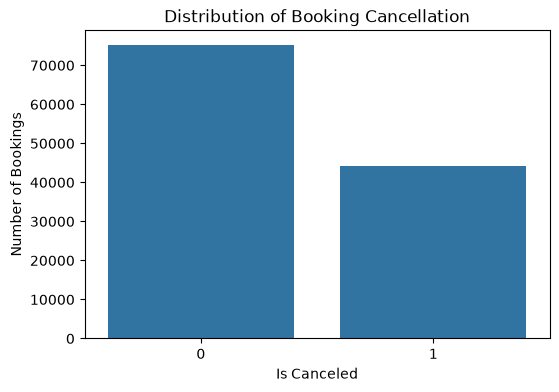

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_canceled")

plt.title("Distribution of Booking Cancellation")
plt.xlabel("Is Canceled")
plt.ylabel("Number of Bookings")
plt.show()

In [14]:
df.shape

(119390, 32)

In [15]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

Task 2 — Cell 1: Missing-value analysis

In [16]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [17]:
missing_table[missing_table["Missing Count"] > 0]

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


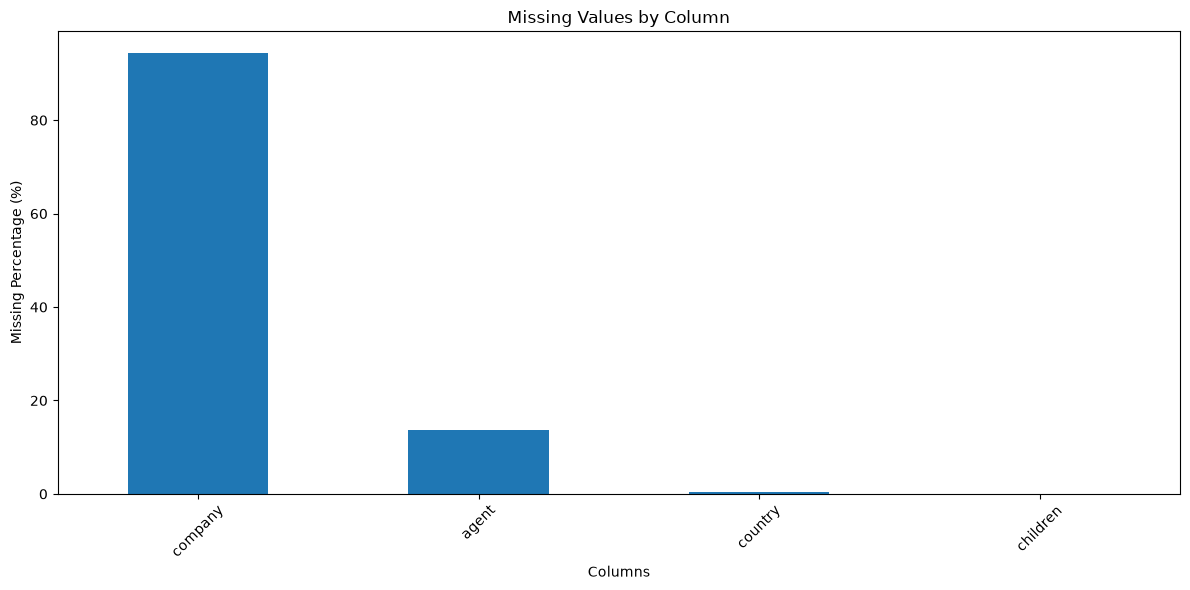

In [18]:
plt.figure(figsize=(12, 6))

missing_table[missing_table["Missing Count"] > 0]["Missing Percentage"].plot(
    kind="bar"
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
high_missing = missing_table[
    missing_table["Missing Percentage"] > 50
]

high_missing

,Missing Count,Missing Percentage
company,112593,94.306893


In [20]:
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_columns)

print("Removed leakage columns:")
print(leakage_columns)

Removed leakage columns:
['reservation_status', 'reservation_status_date']


In [21]:
df = df.drop(columns=["company"])

print("Remaining shape:", df.shape)

Remaining shape: (119390, 29)


Outlier Analysis

In [22]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


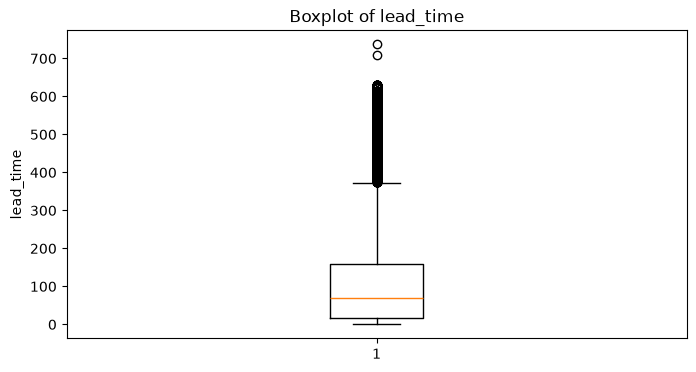

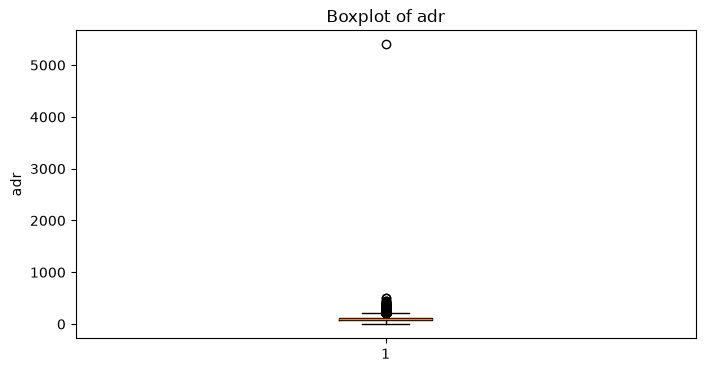

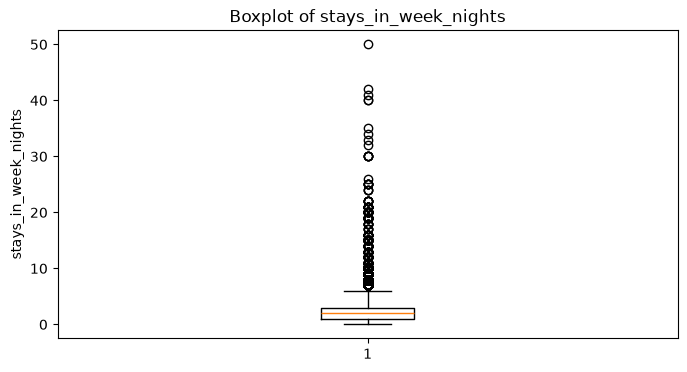

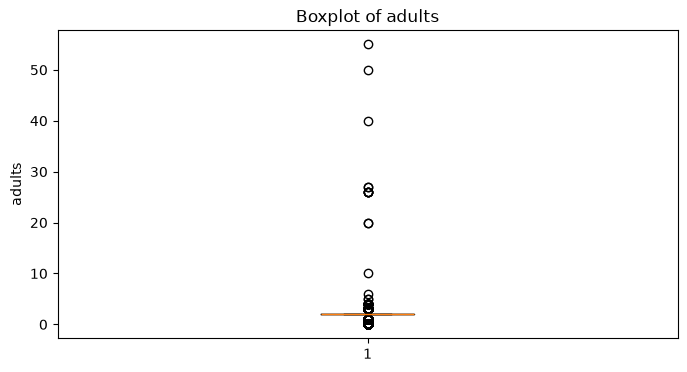

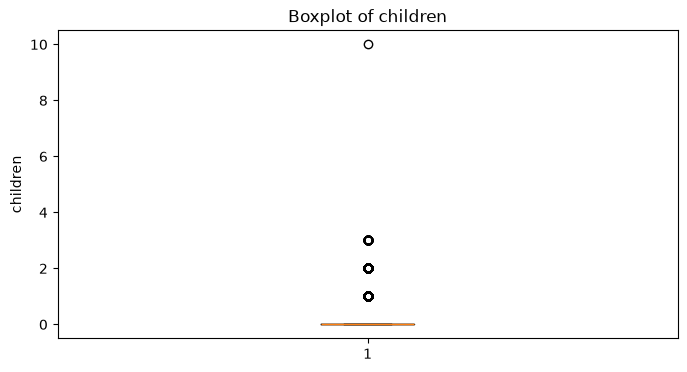

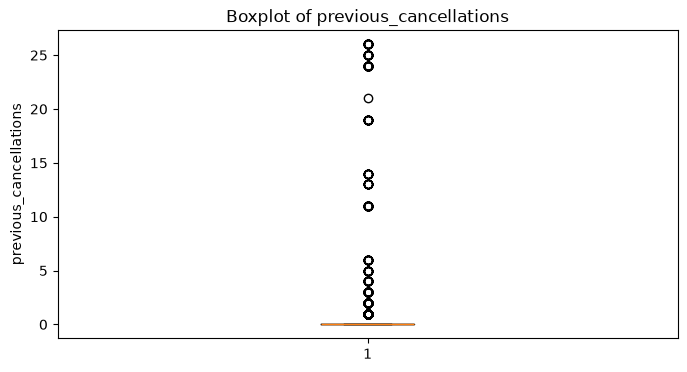

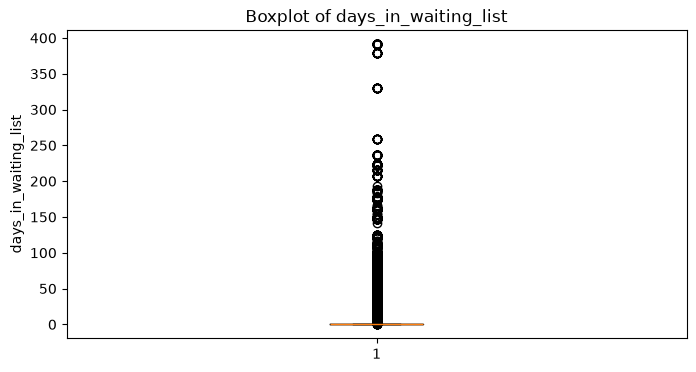

In [23]:
selected_outlier_columns = [
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "adults",
    "children",
    "previous_cancellations",
    "days_in_waiting_list"
]

for column in selected_outlier_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

IQR analysis

In [24]:
def iqr_outlier_count(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return len(outliers), lower_bound, upper_bound


outlier_results = []

for column in selected_outlier_columns:
    count, lower, upper = iqr_outlier_count(df, column)
    
    outlier_results.append({
        "Column": column,
        "Outlier Count": count,
        "Lower Bound": lower,
        "Upper Bound": upper
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table

,Column,Outlier Count,Lower Bound,Upper Bound
0,lead_time,3005,-195.000,373.000
1,adr,3793,-15.775,211.065
2,stays_in_week_nights,3354,-2.000,6.000
3,adults,29710,2.000,2.000
4,children,8590,0.000,0.000
5,previous_cancellations,6484,0.000,0.000
6,days_in_waiting_list,3698,0.000,0.000


In [25]:
df["adr"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
90%         164.000000
95%         193.500000
99%         252.000000
99.5%       275.000000
99.9%       326.201630
max        5400.000000
Name: adr, dtype: float64

In [26]:
df.nlargest(20, "adr")[[
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "hotel",
    "is_canceled"
]]

,adr,adults,children,babies,stays_in_week_nights,stays_in_weekend_nights,hotel,is_canceled
48515,5400.00,2,0.0,0,1,0,City Hotel,1
111403,510.00,1,0.0,0,1,0,City Hotel,0
15083,508.00,2,0.0,0,1,0,Resort Hotel,0
103912,451.50,2,2.0,0,1,1,City Hotel,0
13142,450.00,2,0.0,0,10,4,Resort Hotel,1
13391,437.00,2,2.0,0,4,2,Resort Hotel,1
39155,426.25,2,2.0,0,6,2,Resort Hotel,0
39568,402.00,3,1.0,0,3,2,Resort Hotel,0
39118,397.38,3,2.0,0,5,3,Resort Hotel,0
13323,392.00,2,1.0,0,8,2,Resort Hotel,1


In [27]:
print("Negative ADR:", (df["adr"] < 0).sum())
print("ADR = 0:", (df["adr"] == 0).sum())

Negative ADR: 1
ADR = 0: 1959


In [28]:
df["adr"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
90%         164.000000
95%         193.500000
99%         252.000000
99.5%       275.000000
99.9%       326.201630
max        5400.000000
Name: adr, dtype: float64

In [29]:
df.nlargest(20, "adr")[[
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "hotel",
    "is_canceled"
]]

,adr,adults,children,babies,stays_in_week_nights,stays_in_weekend_nights,hotel,is_canceled
48515,5400.00,2,0.0,0,1,0,City Hotel,1
111403,510.00,1,0.0,0,1,0,City Hotel,0
15083,508.00,2,0.0,0,1,0,Resort Hotel,0
103912,451.50,2,2.0,0,1,1,City Hotel,0
13142,450.00,2,0.0,0,10,4,Resort Hotel,1
13391,437.00,2,2.0,0,4,2,Resort Hotel,1
39155,426.25,2,2.0,0,6,2,Resort Hotel,0
39568,402.00,3,1.0,0,3,2,Resort Hotel,0
39118,397.38,3,2.0,0,5,3,Resort Hotel,0
13323,392.00,2,1.0,0,8,2,Resort Hotel,1


In [30]:
# Identify clear/extreme ADR outliers
extreme_adr = (df["adr"] < 0) | (df["adr"] > 500)

print("Rows with clear/extreme ADR values:", extreme_adr.sum())
print("Rows before removal:", len(df))

# Remove extreme ADR rows
df_clean = df.loc[~extreme_adr].copy()

print("Rows after removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows with clear/extreme ADR values: 4
Rows before removal: 119390
Rows after removal: 119386
Rows removed: 4


In [31]:
df_clean.shape

(119386, 29)

In [32]:
df_clean.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [33]:
df_clean.to_csv("hotel_bookings_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
Task 3 Create X and y

In [34]:
# Separate features and target

X = df_clean.drop(columns=["is_canceled"])
y = df_clean["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119386, 28)
y shape: (119386,)


Identify numerical and categorical columns

In [36]:
# Identify numerical and categorical columns

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (95508, 28)
Testing set: (23878, 28)


In [38]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [39]:
numerical_pipeline_standard = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

preprocessor_A = ColumnTransformer([
    ("num", numerical_pipeline_standard, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [41]:
numerical_pipeline_minmax = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer([
    ("num", numerical_pipeline_minmax, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

Part B - Model Training and Performance Evaluation 
Task 4 - Train Two Classification Models 

In [42]:
logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)

print("Logistic Regression + Pipeline A trained successfully.")

Logistic Regression + Pipeline A trained successfully.


In [43]:
tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B.fit(X_train, y_train)

print("Decision Tree + Pipeline B trained successfully.")

Decision Tree + Pipeline B trained successfully.


In [46]:
logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)

print("Logistic Regression + Pipeline B trained successfully.")

Logistic Regression + Pipeline B trained successfully.


In [44]:
tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)

print("Decision Tree + Pipeline A trained successfully.")

Decision Tree + Pipeline A trained successfully.


Task 5 - Evaluate and Compare the Four Results 

In [47]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "Training Accuracy": accuracy_score(y_train, train_pred),
        "Testing Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred)
    }


results = {
    "Logistic Regression + Pipeline A": evaluate_model(
        logistic_A, X_train, y_train, X_test, y_test
    ),
    "Logistic Regression + Pipeline B": evaluate_model(
        logistic_B, X_train, y_train, X_test, y_test
    ),
    "Decision Tree + Pipeline A": evaluate_model(
        tree_A, X_train, y_train, X_test, y_test
    ),
    "Decision Tree + Pipeline B": evaluate_model(
        tree_B, X_train, y_train, X_test, y_test
    )
}

results_df = pd.DataFrame(results).T

results_df

,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
Logistic Regression + Pipeline A,0.818999,0.816568,0.808144,0.661956,0.727781
Logistic Regression + Pipeline B,0.815366,0.811500,0.802086,0.652007,0.719302
Decision Tree + Pipeline A,0.996220,0.856269,0.802166,0.812323,0.807213
Decision Tree + Pipeline B,0.996220,0.856060,0.801651,0.812436,0.807008


In [48]:
# Predictions for best Logistic Regression and Decision Tree

logistic_best_pred = logistic_A.predict(X_test)
tree_best_pred = tree_A.predict(X_test)

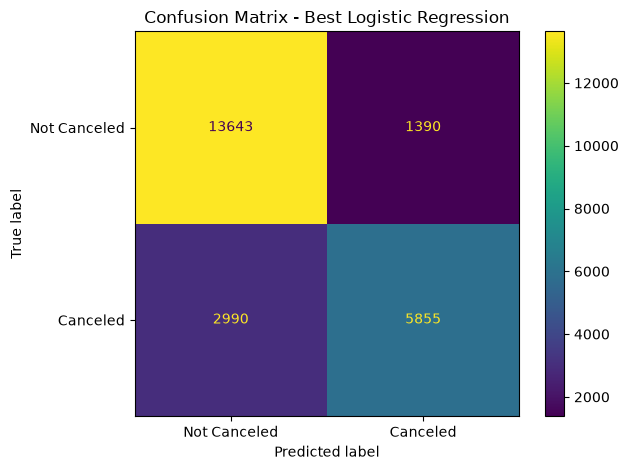

In [49]:
cm_logistic = confusion_matrix(y_test, logistic_best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.tight_layout()

plt.savefig(
    "figures/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

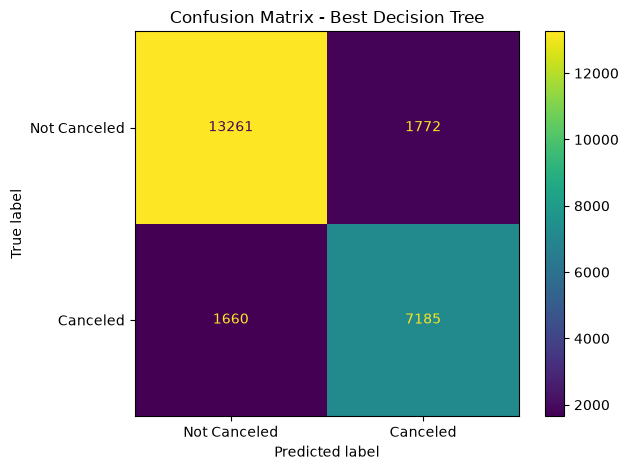

In [50]:
cm_tree = confusion_matrix(y_test, tree_best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Best Decision Tree")
plt.tight_layout()

plt.savefig(
    "figures/confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# Predictions for the best Logistic Regression and Decision Tree models

logistic_best_pred = logistic_A.predict(X_test)
tree_best_pred = tree_A.predict(X_test)

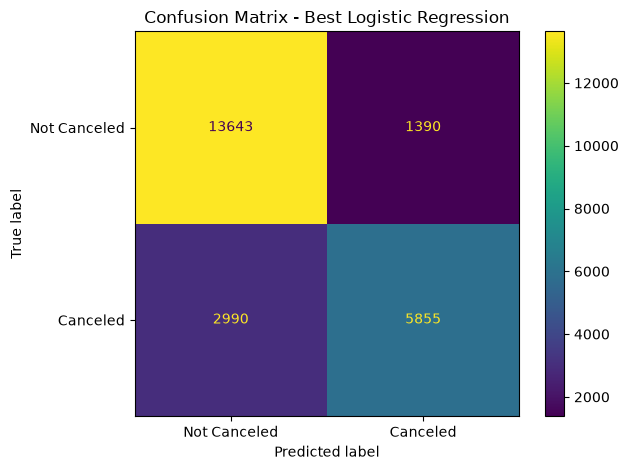

In [52]:
cm_logistic = confusion_matrix(y_test, logistic_best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.tight_layout()

plt.savefig(
    "figures/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 6 - Final Observations

### 1. Which preprocessing-model combination gives the best overall result?

Decision Tree with Pipeline A (KNNImputer + StandardScaler) gives the best overall result. It achieves the highest testing accuracy of 0.856269 and the highest F1-score of 0.807213 among the four experiments.

### 2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?

StandardScaler performs slightly better than MinMaxScaler for Logistic Regression. Pipeline A achieves a testing accuracy of 0.816568 compared with 0.811500 for Pipeline B. The F1-score is also higher with StandardScaler (0.727781 vs. 0.719302).

### 3. Does scaling make a major difference for the Decision Tree?

No. Scaling makes very little difference for the Decision Tree. Pipeline A and Pipeline B produce almost identical results, with testing accuracies of 0.856269 and 0.856060 respectively.

### 4. Overfitting observation

The Decision Tree shows possible overfitting because its training accuracy is 0.996220 while its testing accuracy is approximately 0.856. The large difference between training and testing performance suggests that the tree fits the training data very closely.

### 5. Overall comparison

Logistic Regression has a smaller difference between training and testing accuracy, indicating more stable generalization. However, Decision Tree achieves substantially higher testing accuracy, recall, and F1-score. Therefore, Decision Tree with Pipeline A is the best-performing combination in this experiment.

In [53]:
results_df.round(4)

,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
Logistic Regression + Pipeline A,0.8190,0.8166,0.8081,0.6620,0.7278
Logistic Regression + Pipeline B,0.8154,0.8115,0.8021,0.6520,0.7193
Decision Tree + Pipeline A,0.9962,0.8563,0.8022,0.8123,0.8072
Decision Tree + Pipeline B,0.9962,0.8561,0.8017,0.8124,0.8070


In [54]:
results_df.round(4).to_csv(
    "model_comparison.csv",
    index=True
)

print("Model comparison table saved.")

Model comparison table saved.
